# 🐯 TIGeR — Corrected Cross-Domain Run (ABO)

Companion to `tiger_corrected_run.ipynb`. **This is the notebook that needed
correcting most**, because the two defects that hit hardest were both
ABO-specific.

### Why the previous ABO results cannot stand

**A6 — image repair was switched off for the entire run.**
`arbiter.t2v_policy.allowed_categories` listed the four fashion categories only.
ABO products map to `electronics / furniture / kitchen / home_decor`, so every
E2 and E3 row was force-escalated *before* schema validation or the gamma gate
was consulted. RQ3's image-repair evidence does not exist yet. The high
escalation rate was blamed on the `color` requirement (H10) and on Arbiter
underconfidence (H11); this gate sat upstream of both and is unmentioned in
every document.

**A1 — the gamma ablation never ablated anything.**
It wrote `cfg["fusion"]["gamma"]`; the router reads `cfg["arbiter"]["gamma"]`.
"Full System" and "No Gamma Gate" were the same run, which is why they both
reported 35 repaired / 444 escalated. §7.5 and H11 explain that identity as a
"perfect early exit". There was no early exit to explain.

### What was removed from the old notebook

The old cells **6b/6c** are gone rather than ported:

* Cell 6c's markdown asserted the Arbiter was **overconfident**, *"clustered
  above gamma=0.60, so the gate never fires"* — the direct opposite of H11's
  own conclusion (**underconfident**, 75.2% *below* 0.60). Both statements
  shipped, contradicting each other.
* Its success criterion — *"the new table should show Full System > No Gamma
  Gate"* — was a check A1 made impossible to pass.
* It patched the config with `yaml.dump`, which round-trips the file and
  deletes every comment in it.
* The 25th-percentile rule it applied was justified by the early-exit story
  that A1 invalidated.

The diagnostic is kept below because the *measurement* is still worth having.
The conclusion is not pre-written this time.

**Runtime:** ~30–45 min on a T4.

## Step 0 · Clone the fixed branch and install

In [1]:
!rm -rf TIGeR-Text-Image-Generative-Repair
!git clone -q -b master https://github.com/abdullah2142/TIGeR-Text-Image-Generative-Repair.git
%cd TIGeR-Text-Image-Generative-Repair
!git log --oneline -1

# H7: never --force-reinstall. It rebuilds the dependency tree, pulls an
# incompatible torchvision, and every SigLIP/SDXL cell then dies with
# "operator torchvision::nms does not exist".
!pip uninstall -y tiger -q 2>/dev/null
!pip install --no-cache-dir -e ".[dev,vlm,gen]" -q
print("\n✅ installed")

/kaggle/working/TIGeR-Text-Image-Generative-Repair
caad123 (HEAD -> master, origin/master, origin/HEAD) Default the VLM ablation row off; keep the wiring
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiger (pyproject.toml) ... done

✅ installed


## Step 1 · Guard: confirm the fixes are present

Fails in seconds if the wrong branch was cloned, rather than after 40 minutes of GPU time.

In [2]:
import inspect
from tiger import cli
from tiger.schema import Schema, load_schema
from tiger.fusion import PROBE_TARGETS
from tiger.eval import repair_ablation as RA
from pathlib import Path

checks = []
def check(name, ok, detail=""):
    checks.append((name, bool(ok), detail))

src = inspect.getsource(RA.run_repair_ablations)
check("A1  gamma written to cfg['arbiter']",
      'cfg_no_gamma.setdefault("arbiter", {})["gamma"] = 0.0' in src)
check("A4  configs deep-copied", "copy.deepcopy(cfg)" in src)
check("A3  baseline emits no E4 key",
      '"E4"' not in inspect.getsource(RA.DummyArbiter.predict_proba))
check("A3b baseline is seeded",
      "seed" in inspect.signature(RA.DummyArbiter.__init__).parameters)
check("A5  every audited field scored", hasattr(RA, "truth_from_audit"))
check("A5  image repairs scored", hasattr(RA, "image_provenance"))
check("A7  --fusion flag exposed", '"--fusion"' in inspect.getsource(cli.main))
check("A8  probes scored on-target", isinstance(PROBE_TARGETS, dict) and "color" in PROBE_TARGETS)
check("D5  surface_forms available", hasattr(Schema, "surface_forms"))

# --- Phase 1: the ABO vertical migration ---
from tiger.data.import_abo import CATEGORY_MAP, VERTICALS
from tiger.data import abo_vocab

check("P1  two ABO verticals defined",
      set(VERTICALS) == {"furnishing", "accessories"} and len(CATEGORY_MAP) == 15,
      f"{len(CATEGORY_MAP)} product types")
check("P1  phone cases excluded", "CELLULAR_PHONE_CASE" not in CATEGORY_MAP)
check("P1  colour normaliser present", hasattr(abo_vocab, "normalize_color"))
check("P1  legacy config.yaml gone", not Path("configs/config.yaml").exists())

schema = load_schema("configs/schema.yaml")
dom = schema.domain("color")
check("D5  no duplicate colours in the domain",
      len(dom) == len({schema.normalize("color", v) for v in dom}),
      f"{len(dom)} entries: {dom}")

from tiger.data.synthgen import COLOR_RGB
missing = [c for c in dom if c != "multicolour" and c not in COLOR_RGB]
check("D5  synthgen can render every colour", not missing, f"missing: {missing}")

cfg = cli.load_cfg()
allowed = cfg["arbiter"]["t2v_policy"]["allowed_categories"]
missing_t2v = sorted(set(CATEGORY_MAP.values()) - set(allowed))
check("A6  every ABO category is T2V-eligible", not missing_t2v,
      f"missing: {missing_t2v}" if missing_t2v else f"{len(allowed)} allowed")
check("P1  no ABO category requires colour",
      not (set(CATEGORY_MAP.values())
           & set(schema.attributes["color"].get("required_for_categories", []))),
      "measured coverage is 45-93%; requiring it repeats H10")

# --- 2026-09-14: the estimator rebuild and the routing fixes ---
from tiger import colors, solver, arbiter, sieve
from tiger.generator import build_prompt

check("B2  product localised by connectivity, not a fixed box",
      hasattr(colors, "select_region") and hasattr(colors, "background_mask"))
check("B2  estimate records which region it measured",
      "region" in colors.ColorEstimate.__dataclass_fields__)
check("B5  resize preserves aspect ratio",
      "max(w, h)" in inspect.getsource(colors._load_rgb))
check("B8  value decides at the dark end",
      "dark = v <= BLACK_V_MAX" in inspect.getsource(colors.estimate_dominant_color))
check("B9  a declined colour is not a disagreement",
      "pixel_declined" in solver.RepairPlan.__dataclass_fields__)
check("B4  pixel share is named a share, not a confidence",
      hasattr(solver, "PIXEL_SHARE_MIN"))
check("D1  calibration measured every run", hasattr(arbiter, "calibration_report"))
check("D10 pattern and material reach the T2V prompt",
      "striped pattern" in build_prompt("x", "chair",
                                        {"color": "red", "pattern": "striped"})[1])
check("D10 generator uses the shared singular table",
      build_prompt("x", "wall_art", {"color": "blue"})[1] == "blue piece of wall art")

# D15: the title check must not fire on a title that merely lists colours,
# nor on jewellery metal names. Both were ~93% of the dismiss blockage.
_tc = lambda t: sieve._title_color(t, schema, "")
check("D15 multi-colour titles are not contradictions",
      _tc("Wool Area Rug, Blue, Grey, Brown") == "")
check("D15 jewellery metal names are materials",
      _tc("Sterling Silver Halo Pendant Necklace") == "")
check("D15 a single contradicting colour still fires",
      _tc("Solid Red Dining Chair") == "red")

# D14: the dismiss guard must be STRICTER than the Sieve threshold that flags
# the row, or it vetoes every row it is asked about.
_gz = float(cfg["arbiter"].get("dismiss_contrary_z", -2.0))
_fz = -float(cfg["sieve"]["probes"]["z_margin"])
check("D14 dismiss guard is stricter than the flag threshold",
      _gz < _fz, f"guard {_gz} vs flag {_fz}")

check("D17 T2V verifier can reject a choice",
      "runner_up_image_path" in inspect.signature(
          __import__("tiger.verify", fromlist=["x"]).IndependentVerifier.check_t2v).parameters)

width = max(len(n) for n, _, _ in checks)
for name, ok, detail in checks:
    print(f"{'PASS' if ok else 'FAIL'}  {name:<{width}}  {detail}")

failed = [n for n, ok, _ in checks if not ok]
assert not failed, f"\n\nWRONG BRANCH OR STALE INSTALL. Missing: {failed}"
print("\n✅ all fixes present — safe to proceed")

PASS  A1  gamma written to cfg['arbiter']                     
PASS  A4  configs deep-copied                                 
PASS  A3  baseline emits no E4 key                            
PASS  A3b baseline is seeded                                  
PASS  A5  every audited field scored                          
PASS  A5  image repairs scored                                
PASS  A7  --fusion flag exposed                               
PASS  A8  probes scored on-target                             
PASS  D5  surface_forms available                             
PASS  P1  two ABO verticals defined                           15 product types
PASS  P1  phone cases excluded                                
PASS  P1  colour normaliser present                           
PASS  P1  legacy config.yaml gone                             
PASS  D5  no duplicate colours in the domain                  12 entries: ['red', 'blue', 'green', 'black', 'white', 'yellow', 'pink', 'purple', 'brown', 'orange', '

## Step 2 · Test suite (162)

In [3]:
!python -m pytest -q 2>&1 | tail -5

........................................................................ [ 30%]
........................................................................ [ 61%]
........................................................................ [ 91%]
...................                                                      [100%]


## Step 3 · Pin γ and record it

γ = 0.60 is the value the *original* ABO run used, confirmed by the committed
histogram's own caption. Starting here makes the corrected numbers directly
comparable to the ones in the paper. The diagnostic later measures whether it is
the right choice for this domain — it no longer assumes the answer.

In [4]:
import json, re, yaml
from pathlib import Path

GAMMA = 0.60          # operating point for THIS run
NOISE_SEED = 7
BASELINE_SEED = 42    # seeds the random-routing baseline (A3b)

cfg_path = Path("configs/tiger.yaml")
text = cfg_path.read_text()

# Surgical line edit, NOT yaml.safe_dump: dumping would round-trip the file and
# silently delete every comment in it, including the rationale for the T2V
# allowlist and the noise rates. Config comments are the only place several of
# these decisions are recorded.
# Replace the whole line including its trailing comment. Leaving the old
# comment behind ("lowered from 0.60 ...") next to a value of 0.60 is precisely
# the config/doc drift that produced finding C1 in the first place.
text, n = re.subn(
    r"^(\s*)gamma:.*$",
    rf"\g<1>gamma: {GAMMA}  # Eq. 22 confidence gate; pinned by tiger_corrected_run.ipynb",
    text, count=1, flags=re.M)
assert n == 1, "could not find `gamma:` in configs/tiger.yaml"

if not re.search(r"^eval:", text, flags=re.M):
    text += ("\neval:\n"
             "  # Seeds the random-routing baseline so the 'No Arbiter' row is\n"
             "  # reproducible (finding A3b).\n"
             f"  random_baseline_seed: {BASELINE_SEED}\n")
else:
    text, n = re.subn(r"^(\s*random_baseline_seed:\s*)\d+", rf"\g<1>{BASELINE_SEED}",
                      text, count=1, flags=re.M)
    assert n == 1
cfg_path.write_text(text)

cfg = yaml.safe_load(cfg_path.read_text())
assert cfg["arbiter"]["gamma"] == GAMMA
assert cfg["eval"]["random_baseline_seed"] == BASELINE_SEED

manifest = {
    "branch": "docs/fixes-backlog-audit",
    "gamma": GAMMA,
    "noise_seed": NOISE_SEED,
    "random_baseline_seed": BASELINE_SEED,
    "dismiss_threshold": cfg["arbiter"]["dismiss_threshold"],
    "t2v_allowed_categories": cfg["arbiter"]["t2v_policy"]["allowed_categories"],
    "precision_floor": cfg["sieve"]["precision_floor"],
    "clip_model": cfg["models"]["clip_model_name"],
    "independent_verifier": cfg["models"]["independent_verifier"],
    "fusion_applied": False,
}
Path("data/outputs").mkdir(parents=True, exist_ok=True)
Path("data/outputs/run_manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

{
  "branch": "docs/fixes-backlog-audit",
  "gamma": 0.6,
  "noise_seed": 7,
  "random_baseline_seed": 42,
  "dismiss_threshold": 0.8,
  "t2v_allowed_categories": [
    "shirts",
    "shoes",
    "bags",
    "hats",
    "chair",
    "sofa",
    "table",
    "ottoman",
    "stool",
    "rug",
    "lamp",
    "light_fixture",
    "wall_art",
    "ring",
    "necklace",
    "earring",
    "handbag",
    "suitcase",
    "hat"
  ],
  "precision_floor": 0.85,
  "clip_model": "openai/clip-vit-base-patch32",
  "independent_verifier": "google/siglip-base-patch16-224",
  "fusion_applied": false
}


---
## Step 4 · Download ABO from the official source

Pulled from **`s3://amazon-berkeley-objects/`**, the AWS Registry of Open Data
release — not a third-party Kaggle mirror. This is what makes the dataset
citable as *Collins et al., "ABO: Dataset and Benchmarks for Real-World 3D
Object Understanding", CVPR 2022*.

Two archives, ~3.3 GB total, no credentials required:

| Archive | Size | Contents |
|---|---|---|
| `abo-listings.tar` | 87 MB | `listings/metadata/listings_*.json.gz` |
| `abo-images-small.tar` | 3.25 GB | `images/metadata/images.csv.gz`, `images/small/**` |

**Licence:** the S3 bucket ships `LICENSE-CC-BY-4.0.txt`, while the AWS registry
entry states CC BY-NC 4.0. Read the licence file in the download and cite what
it actually says — the two sources disagree and the NC clause would matter for
any commercial claim.

The official archives are **gzipped**. The adapter previously globbed
`listings_*.json` and called plain `open()`, so the canonical source raised
"No listings_*.json files found" and only the decompressed Kaggle mirror
worked. Fixed on this branch and covered by tests.

In [5]:
import os, subprocess, tarfile
from pathlib import Path

ABO = Path("/kaggle/working/abo")
ABO.mkdir(parents=True, exist_ok=True)
BASE = "https://amazon-berkeley-objects.s3.amazonaws.com/archives"

for name in ("abo-listings.tar", "abo-images-small.tar"):
    tar = ABO / name
    if tar.exists():
        print(f"{name}: already downloaded ({tar.stat().st_size/1e9:.2f} GB)")
        continue
    print(f"downloading {name} ...")
    subprocess.run(["curl", "-fL", "--retry", "3", "-o", str(tar), f"{BASE}/{name}"], check=True)
    print(f"  {tar.stat().st_size/1e9:.2f} GB")

for name in ("abo-listings.tar", "abo-images-small.tar"):
    marker = ABO / f".extracted_{name}"
    if marker.exists():
        print(f"{name}: already extracted"); continue
    print(f"extracting {name} ...")
    with tarfile.open(ABO / name) as t:
        t.extractall(ABO)
    marker.touch()

# Read the licence as shipped rather than assuming which of the two it is.
lic = next(iter(ABO.rglob("LICENSE*")), None)
print("\nlicence file:", lic.name if lic else "not found")
if lic:
    print(lic.read_text(errors="replace")[:300].strip().replace("\n", " ")[:280])

downloading abo-listings.tar ...


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 83.4M  100 83.4M    0     0  28.6M      0  0:00:02  0:00:02 --:--:-- 28.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0.09 GB
downloading abo-images-small.tar ...


100 3102M  100 3102M    0     0  34.8M      0  0:01:28  0:01:28 --:--:-- 34.5M
/tmp/ipykernel_23/373047313.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(ABO)


  3.25 GB
extracting abo-listings.tar ...
extracting abo-images-small.tar ...

licence file: LICENSE-CC-BY-4.0.txt
Creative Commons Attribution 4.0 International Public License  By exercising the Licensed Rights (defined below), You accept and agree to be bound by the terms and conditions of this Creative Commons Attribution 4.0 International Public License ("Public License"). To the extent t


In [6]:
from pathlib import Path

LISTINGS_DIR = next(p for p in ABO.rglob("listings/metadata") if p.is_dir())
IMAGES_CSV   = next(iter(list(ABO.rglob("images.csv.gz")) + list(ABO.rglob("images.csv"))))
IMAGES_DIR   = next(p for p in ABO.rglob("images/small") if p.is_dir())

print("listings   ", LISTINGS_DIR, f"({len(list(LISTINGS_DIR.glob('listings_*')))} files)")
print("images.csv ", IMAGES_CSV)
print("images dir ", IMAGES_DIR)

# The canonical archive is gzipped; the Kaggle mirror was not. Both are fine now.
gz = list(LISTINGS_DIR.glob("listings_*.json.gz"))
print(f"\nlayout: {'official (.json.gz)' if gz else 'decompressed (.json)'}")

listings    /kaggle/working/abo/listings/metadata (16 files)
images.csv  /kaggle/working/abo/images/metadata/images.csv.gz
images dir  /kaggle/working/abo/images/small

layout: official (.json.gz)


In [7]:
!python -m tiger.cli import-abo \
    --listings-dir {LISTINGS_DIR} \
    --images-csv {IMAGES_CSV} \
    --images-dir {IMAGES_DIR} \
    --max-items 20000 \
    --max-per-category 1200

Importing ABO from:
  listings : /kaggle/working/abo/listings/metadata
  images   : /kaggle/working/abo/images/metadata/images.csv.gz
  img dir  : /kaggle/working/abo/images/small
category       split      
chair          calibration    616
               report         584
earring        calibration    349
               report         378
handbag        calibration    334
               report         348
hat            calibration    198
               report         212
lamp           calibration    243
               report         214
light_fixture  calibration    242
               report         242
necklace       calibration    466
               report         473
ottoman        calibration    179
               report         184
ring           calibration    484
               report         426
rug            calibration    409
               report         408
sofa           calibration    500
               report         497
stool          calibration    170
           

### Validate the import

H3 produced 0–16 products out of 147,000 while exiting cleanly. Check the shape, not just the exit code.

In [8]:
import json
import pandas as pd
from tiger.data.import_abo import CATEGORY_MAP, VERTICALS
from tiger.schema import load_schema

schema = load_schema("configs/schema.yaml")
df = pd.read_parquet("data/sample/products.parquet")
assert len(df) > 5000, f"only {len(df)} products imported — see H3/H4/H5"
df["a"] = df["attributes"].map(json.loads)

cov = df.groupby("category").agg(
    n=("a", "size"),
    colour=("a", lambda s: sum("color" in x for x in s) / len(s)),
    material=("a", lambda s: sum("material" in x for x in s) / len(s)),
)
cov["vertical"] = [next(v for v, m in VERTICALS.items() if c in m) for c in cov.index]
print(f"{len(df)} products\n")
print(cov.sort_values(["vertical", "n"], ascending=[True, False])
         .to_string(float_format=lambda v: f"{v:.1%}"))
print("\nsplit:", df["split"].value_counts().to_dict())

# Every row must validate, or it is flagged dirty before any repair is attempted.
inv = sum(1 for r in df.itertuples() if schema.validate_attrs(r.category, r.a))
assert inv == 0, f"{inv} schema-invalid rows — check required_for_categories (H10)"
print("\n✅ 0 schema-invalid rows")

# Local reference run: 11,839 products, 73.3% colour, 53.9% material.
print(f"colour {sum('color' in x for x in df.a)/len(df):.1%} | "
      f"material {sum('material' in x for x in df.a)/len(df):.1%}")

9953 products

                  n  colour  material     vertical
category                                          
necklace        939   70.9%     44.8%  accessories
ring            910   63.6%     20.7%  accessories
earring         727   74.8%     42.8%  accessories
handbag         682   90.5%     78.2%  accessories
hat             410   46.6%     26.1%  accessories
suitcase        256   89.1%     46.1%  accessories
chair          1200   77.9%     62.7%   furnishing
sofa            997   84.1%     72.5%   furnishing
rug             817   77.8%     86.2%   furnishing
table           747   70.3%     74.2%   furnishing
wall_art        598   92.8%     80.1%   furnishing
light_fixture   484   91.9%     63.4%   furnishing
lamp            457   94.5%     60.2%   furnishing
stool           366   82.5%     35.0%   furnishing
ottoman         363   82.1%     76.3%   furnishing

split: {'report': 4977, 'calibration': 4976}

✅ 0 schema-invalid rows
colour 78.3% | material 59.0%


---
## Step 5 · Calibrate on the ABO distribution

Thresholds, router and fusion are all domain-specific and must be refitted.
`train-arbiter` runs eight noise seeds end to end — this is the slow cell.

In [9]:
!python -m tiger.cli calibrate

locked thresholds -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_locked_thresholds.json
LOO calibration -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_loo_calibration.json
verify epsilon=0.0318 (by category: {'sofa': 0.0294, 'table': 0.0316, 'chair': 0.0283, 'wall_art': 0.0385, 'suitcase': 0.0424, 'light_fixture': 0.0426, 'rug': 0.032, 'necklace': 0.0223, 'ring': 0.029, 'hat': 0.0299, 'earring': 0.0296, 'handbag': 0.0225, 'lamp': 0.0372, 'ottoman': 0.0297, 'stool': 0.0277}) -> /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_verify_calibration.json


In [10]:
!python -m tiger.cli noise --seed 7

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_seed7.parquet
{
  "seed": 7,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 4977,
  "rows_noisy": 1476,
  "by_label": {
    "clean": 3501,
    "mutate_text": 679,
    "swap_image": 647,
    "mixed": 100,
    "missing_image": 50
  },
  "by_subtype": {
    "swap_image": 498,
    "color_flip": 299,
    "swap_image_same_category": 149,
    "title_contradiction": 100,
    "material_flip": 100,
    "mixed_swap_color": 100,
    "near_color_flip": 100,
    "attribute_drop": 80,
    "missing_image": 50
  },
  "self_verified": true
}


## Step 4b · Detection metrics on ABO

The detection table in the paper comes from the *synthetic* catalogue. ABO has
never had one, because this notebook is the repair notebook — it runs `noise`
and goes straight to routing. That left a real result with nowhere to live: the
`D15` title-check fix removed 336 false flags from the 2026-09-14 run (clean
rows flagged 575 → 315), which is a **detection** improvement measured only as
a side effect of the repair run's row counts.

`sweep` runs noise → detect → evaluate across seeds and reports precision,
recall, F1 and per-error-type recall with a product-level bootstrap — the same
instrument the synthetic table uses, so the two are directly comparable. It
runs before any repair, which is where detection belongs.

Cost: image embeddings are content-hash cached, so only the first seed pays for
them; later seeds re-encode captions only. Drop to `--seeds 7` if you are short
of time — you lose the error bars, not the numbers.

In [11]:
!python -m tiger.cli sweep --seeds 7,8,9,10,11

import json as _json
from pathlib import Path as _P

_m = _P("data/outputs/detection_metrics_sweep.json")
if not _m.exists():
    print("sweep produced no metrics file")
else:
    _d = _json.loads(_m.read_text())["pooled"]
    _c = _d["confusion"]
    print(f"\npooled over 5 seeds: P={_d['precision']:.3f}  R={_d['recall']:.3f}  F1={_d['f1']:.3f}")
    print(f"flagged {_c['tp'] + _c['fp']} rows: {_c['tp']} dirty, {_c['fp']} clean")

    print("\nrecall by error type:")
    for _k, _v in sorted(_d["recall_by_label"].items()):
        print(f"   {_k:22s} {_v['recall']:.3f}  ({_v['caught']}/{_v['total']})")

    # D15: the title check was firing on 15.9% of clean rows, which is a
    # DETECTION defect as much as a routing one -- this is where that shows.
    # Anything below ~0.5 is flagging clean rows more often than dirty ones.
    print("\nper-signal precision (share of the rows each signal flags that are really dirty):")
    for _k, _v in sorted(_d["signal_precision"].items()):
        if _v.get("precision") is None:
            print(f"   {_k:28s} never fired")
        else:
            print(f"   {_k:28s} {_v['precision']:.3f}  (fired on {_v['fired']} rows)")

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_seed7.parquet
{
  "seed": 7,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 4977,
  "rows_noisy": 1476,
  "by_label": {
    "clean": 3501,
    "mutate_text": 679,
    "swap_image": 647,
    "mixed": 100,
    "missing_image": 50
  },
  "by_subtype": {
    "swap_image": 498,
    "color_flip": 299,
    "swap_image_same_category": 149,
    "title_contradiction": 100,
    "material_flip": 100,
    "mixed_swap_color": 100,
    "near_color_flip": 100,
    "attribute_drop": 80,
    "missing_image": 50
  },
  "self_verified": true
}


📊 Stage 1: Error Detection Complete
--------------------------------------------------
operating point: full (OR-fu

### Step 4c · Which encoder should the probes use? (B7)

`compare-encoders` scores each candidate encoder by **per-field probe
accuracy** on the clean catalogue — does it pick the declared value out of the
field's domain — which is the selection criterion the review asked for, not
global similarity. It has never actually been run: no `encoder_comparison.json`
exists anywhere in the repo, so the claim that CLIP is the weakest available
encoder for this task rests on ARO's published numbers, not on this corpus.

CLIP is measured at 62% on ARO attribute binding against BLIP's 88%; SigLIP is
already installed here as the independent verifier, so it costs nothing to ask.
If SigLIP wins on colour/material/pattern, `models.probe_model_name` moves the
probes onto it while similarity, swap and LOO stay on the reported CLIP
baseline (B7 wiring). If it does not win, that is a finding too — and a cheaper
one than swapping first and measuring afterwards.

In [12]:
!python -m tiger.cli compare-encoders

import json as _json
from pathlib import Path as _P
_e = _P("data/outputs/encoder_comparison.json")
if _e.exists():
    _r = _json.loads(_e.read_text())
    _fields = sorted({f for v in _r.values() for f in v})
    print(f"\n{'field':10s} " + "  ".join(f"{n.split('/')[-1][:24]:>24s}" for n in _r))
    for _f in _fields:
        _cells = []
        for _n in _r:
            _v = _r[_n].get(_f, {})
            _cells.append(f"{_v.get('accuracy', float('nan')):.3f} ({_v.get('total', 0)})")
        print(f"{_f:10s} " + "  ".join(f"{_c:>24s}" for _c in _cells))
    print("\nHigher is better. Set models.probe_model_name to the winner to move")
    print("ONLY the probes onto it; every other signal stays on the CLIP baseline.")
else:
    print("no encoder_comparison.json produced")

=== per-field probe accuracy on 9953 clean products ===
field      openai/clip-vit-base-p  google/siglip-base-pat
---------------------------------------------------------
color                 0.545 (7791)             0.604 (7791)
material              0.206 (5877)             0.328 (5877)
pattern                 nan (  0)               nan (  0)

baseline (reported): openai/clip-vit-base-patch32
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/outputs/encoder_comparison.json

field         clip-vit-base-patch32   siglip-base-patch16-224
color                  0.545 (7791)              0.604 (7791)
material               0.206 (5877)              0.328 (5877)
pattern                     nan (0)                   nan (0)

Higher is better. Set models.probe_model_name to the winner to move
ONLY the probes onto it; every other signal stays on the CLIP baseline.


In [13]:
!python -m tiger.cli train-arbiter

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/processed/noisy_report_cal_seed1007.parquet
{
  "seed": 1007,
  "copies_per_row": 1,
  "rates": {
    "swap_image": 0.1,
    "swap_image_same_category": 0.03,
    "color_flip": 0.06,
    "near_color_flip": 0.02,
    "material_flip": 0.02,
    "attribute_drop": 0.02,
    "title_contradiction": 0.02,
    "mixed_swap_color": 0.02,
    "missing_image": 0.01
  },
  "rows_total": 4976,
  "rows_noisy": 1479,
  "by_label": {
    "clean": 3497,
    "mutate_text": 682,
    "swap_image": 647,
    "mixed": 100,
    "missing_image": 50
  },
  "by_subtype": {
    "swap_image": 498,
    "color_flip": 299,
    "swap_image_same_category": 149,
    "title_contradiction": 100,
    "material_flip": 100,
    "near_color_flip": 100,
    "mixed_swap_color": 100,
    "attribute_drop": 83,
    "missing_image": 50
  },
  "self_verified": true
}


📊 Stage 1: Error Detection Complete
--------------------------------------------------
operating point: f

In [14]:
!python -m tiger.cli calibrate-fusion

precision floor 0.85; calibrated on 39808 labelled rows
  flag_probe_color           precision=0.901 fired=790 z>=3.0
  flag_probe_material        precision=0.863 fired=400 z>=3.0
  flag_probe_pattern         precision=None fired=0 z>=4.0 QUARANTINED
  flag_low_sim               precision=0.876 fired=4710
  flag_text_out_of_domain    precision=None fired=0
  flag_title_contradiction   precision=0.496 fired=3107
wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/data/thresholds/tiger_fusion.json


---
## Step 6 · The corrected repair ablation

First time this runs with image repair actually enabled for ABO categories.

**Two verifiers, two rows (E13/D16/D17).** `--independent` is the second-encoder
cross-check (SigLIP); `--vlm-judge` is Gemini, which judges the proposed image
against the description on its own terms and is the only identity-aware check
available. They are now separate ablation configs rather than one standing in
for the other — every previously committed row labelled "No VLM Judge" actually
ablated SigLIP, and no VLM had ever run.

This matters because the encoder verifier **cannot reject a T2V swap**: it
approved 304 of 304 (D17). The VLM row is the test of whether an identity-aware
judge catches what similarity cannot — the generic wooden chair installed over a
specific black leather chaise.

**Cost:** the VLM row makes one rate-limited API call per repair (LRU-cached),
so expect it to be the slowest cell in the notebook. Drop `--vlm-judge` to skip
it; every other row is unaffected.

**Why the VLM row is off by default.** `project_chronicle.md` records a
Gemini-vs-SigLIP comparison that chose SigLIP — but it was decided at **+13.3%
vs +13.1%** (a 0.2-point gap, i.e. noise), on the **Fashion** dataset which this
project no longer uses, and crucially **before D17**. At that time SigLIP's T2V
check was the circular one that approves everything, so its +13.3% came entirely
from the V2T side; Gemini's T2V check was never circular. The two have therefore
never been compared on the axis D16 is about.

That makes Gemini worth testing *eventually*, not now. D17's runner-up check is
the new variable and it is unmeasured: if it makes the encoder verifier start
rejecting, D16 may be answered without spending any quota. If the T2V
`independent_ok` split still comes back 100% True, that is the signal to set
`ENABLE_VLM_ROW = True` — and Gemini's free tier is 500 requests/day, which a
450-item ablation has already exhausted once, so spend it deliberately.

In [15]:
import os, subprocess

# The VLM row is OFF by default. Flip to True only once there is a reason to
# spend the quota -- see the note above the cell.
ENABLE_VLM_ROW = False

_vlm = ""
if ENABLE_VLM_ROW:
    # The Gemini key lives in .env, which is gitignored, so on Kaggle it must
    # come from Secrets (Add-ons -> Secrets, named GEMINI_API_KEY). The judge
    # fail-fasts on a missing key rather than degrading into a silent 100% veto
    # (A2), so without this the whole cell would die.
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ["GEMINI_API_KEY"] = UserSecretsClient().get_secret("GEMINI_API_KEY")
        _vlm = "--vlm-judge "
        print("Gemini key loaded from Kaggle Secrets -> VLM Judge row ENABLED")
    except Exception as _e:
        print(f"no Gemini key ({type(_e).__name__}) -> VLM Judge row SKIPPED, "
              f"everything else runs normally")
else:
    print("VLM Judge row disabled (ENABLE_VLM_ROW = False)")

_cmd = f"python -m tiger.cli ablate-repair --independent {_vlm}--generative-fallback"
print(f"\n$ {_cmd}\n")
subprocess.run(_cmd, shell=True, check=True)

VLM Judge row disabled (ENABLE_VLM_ROW = False)

$ python -m tiger.cli ablate-repair --independent --generative-fallback



Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


[config] effective arbiter.gamma = 0.6 (from config)


Loading pipeline components...: 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]


  Sampled 1476 corrupted + 2952 clean = 4428 total rows

Running repair ablations on the full dataset...
1/5: Running 'Full System'...
  wrote repaired_report_seed7.parquet and repair_report_seed7.json (Full System, per-row)
2/5: Running 'No Arbiter (Random Routing)'...
3/5: Running 'No Independent Verifier'...
4/5: Running 'No Generative Fallback'...
5/5: Running 'No Gamma Gate (Accept All Routes)'...

🛠️ Repair-Side Ablation Study: Component Impact

Configuration             | Repaired | Escalated  | Attr restored    | Image restored  
-----------------------------------------------------------------------------------------------
No Arbiter (Random)       | 5        | 1196       | 0.0% (n=1)       | 40.0% (n=5)     
No Independent Verifier   | 325      | 848        | 31.7% (n=101)    | 36.9% (n=225)   
No Generative Fallback    | 183      | 991        | 46.2% (n=65)     | 45.0% (n=111)   
No Gamma Gate (γ=0)       | 366      | 805        | 39.7% (n=126)    | 41.7% (n=235)   
Full Sys

CompletedProcess(args='python -m tiger.cli ablate-repair --independent --generative-fallback', returncode=0)

## Step 7 · Results

Two checks matter more than the raw numbers.

In [16]:
import pandas as pd
pd.set_option("display.width", 200, "display.max_columns", 50)

df = pd.read_csv("data/outputs/repair_ablations_summary.csv")
cols = [c for c in ["Configuration", "Repaired", "Escalated", "Total Attempted",
                    "Attr Accuracy", "Attr Cases", "T2V Accuracy", "T2V Cases",
                    "Color Accuracy", "V2T Cases"] if c in df.columns]
display(df[cols])

full = df[df["Configuration"] == "Full System"]
nog  = df[df["Configuration"].str.contains("Gamma", na=False)]

print("\n--- A1: is the gamma gate genuinely ablated now? ---")
if len(full) and len(nog):
    if (full["Repaired"].iat[0] == nog["Repaired"].iat[0]
            and full["Escalated"].iat[0] == nog["Escalated"].iat[0]):
        print("STILL IDENTICAL. Previously this was the A1 bug. If it persists on the "
              "fixed branch it is a real finding — but prove it by intersecting the "
              "escalated row_id sets (E3). Equal totals are not equal sets.")
    else:
        print("Different ✅ — the gate is being ablated for the first time.")

print("\n--- A6: did any image repair actually happen? ---")
t2v = full["T2V Cases"].iat[0] if ("T2V Cases" in full and len(full)) else 0
print(f"T2V repairs attempted in Full System: {t2v}")
print("0 means image repair is still blocked somewhere — investigate before "
      "reporting anything about RQ3." if not t2v else
      "Non-zero ✅ — cross-domain image repair ran for the first time.")

,Configuration,Repaired,Escalated,Total Attempted,Attr Accuracy,Attr Cases,T2V Accuracy,T2V Cases,Color Accuracy,V2T Cases
0,No Arbiter (Random),5,1196,1201,0.000000,1,0.400000,5,0.000000,1
1,No Independent Verifier,325,848,1173,0.316832,101,0.368889,225,0.344086,93
2,No Generative Fallback,183,991,1174,0.461538,65,0.450450,111,0.476190,63
3,No Gamma Gate (gamma=0),366,805,1171,0.396825,126,0.417021,235,0.413223,121
4,Full System,183,991,1174,0.461538,65,0.450450,111,0.476190,63



--- A1: is the gamma gate genuinely ablated now? ---
Different ✅ — the gate is being ablated for the first time.

--- A6: did any image repair actually happen? ---
T2V repairs attempted in Full System: 111
Non-zero ✅ — cross-domain image repair ran for the first time.


In [17]:
import json
from pathlib import Path

d4 = json.loads(Path("data/outputs/repair_ablations.json").read_text()).get("full", {})
dist = d4.get("passes_used_distribution", {})
multi = d4.get("multi_pass_rows", 0)
both = d4.get("both_directions_rows", 0)

print("--- D4: did any row actually get a second pass? ---")
print(f"passes_used distribution (Full System): {dist}")
print(f"rows that reached pass 2+: {multi}")
print(f"rows that got BOTH a T2V and a V2T repair (the direct signature of D4 working): {both}")
if multi and both:
    print("Non-zero on both \u2705 \u2014 the two-pass re-diagnosis loop fired on real rows,")
    print("not just in the unit tests (tests/test_repair_two_pass.py).")
else:
    print("Zero here does not mean D4 is broken \u2014 it means no row in this sample")
    print("needed both an image and a text fix this run. Check the E3/BOTH share of")
    print("the Arbiter's routing output (cell above) to see how common that should be.")


--- D4: did any row actually get a second pass? ---
passes_used distribution (Full System): {'1': 1231, '2': 20}
rows that reached pass 2+: 20
rows that got BOTH a T2V and a V2T repair (the direct signature of D4 working): 0
Zero here does not mean D4 is broken — it means no row in this sample
needed both an image and a text fix this run. Check the E3/BOTH share of
the Arbiter's routing output (cell above) to see how common that should be.


## Step 8 · Arbiter confidence diagnostic

Measures the confidence distribution. **It does not tell you what to conclude.**

The previous version asserted the answer in its own markdown before running —
and asserted it in the direction opposite to the roadmap's finding. Read the
numbers this time.

Interpreting it: mass far below γ means the router is underconfident here and
escalates most rows on principle. Mass far above means γ never binds. Neither
is automatically wrong; both are facts about a router trained on fashion noise
and applied to furniture.

n=1291  mean=0.636  median=0.621
below gamma=0.6: 43.9%
p25=0.538  p75=0.729
predicted classes: {'E1': 372, 'E2': 293, 'E3': 234, 'CLEAN': 392}


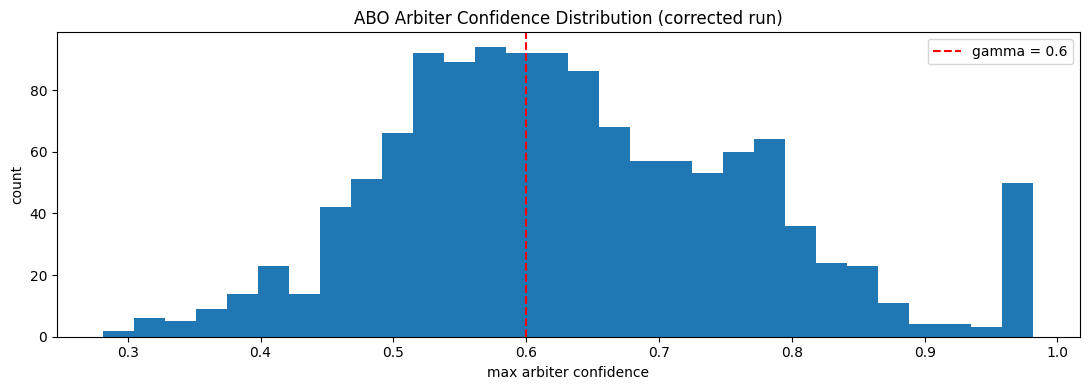

In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tiger.arbiter import ArbiterModel, featurize, CLASSES

model = ArbiterModel.from_json(Path("data/thresholds/tiger_arbiter_model.json").read_text())
ev_files = sorted(Path("data/outputs").glob("evidence_cal_seed*.jsonl"))
assert ev_files, "run train-arbiter first"
records = [json.loads(l) for l in ev_files[-1].read_text().splitlines() if l.strip()]

max_probs, preds = [], []
for ev in records:
    p = model.predict_proba(featurize(ev))
    top = max(p, key=p.get)
    max_probs.append(p[top]); preds.append(top)
max_probs = np.array(max_probs)

GAMMA = json.loads(Path("data/outputs/run_manifest.json").read_text())["gamma"]
print(f"n={len(max_probs)}  mean={max_probs.mean():.3f}  median={np.median(max_probs):.3f}")
print(f"below gamma={GAMMA}: {(max_probs < GAMMA).mean()*100:.1f}%")
print(f"p25={np.percentile(max_probs,25):.3f}  p75={np.percentile(max_probs,75):.3f}")
print(f"predicted classes: { {c: preds.count(c) for c in CLASSES} }")

plt.figure(figsize=(11, 4))
plt.hist(max_probs, bins=30)
plt.axvline(GAMMA, color="red", ls="--", label=f"gamma = {GAMMA}")
plt.xlabel("max arbiter confidence"); plt.ylabel("count")
plt.title("ABO Arbiter Confidence Distribution (corrected run)")
plt.legend(); plt.tight_layout()
Path("paper_figures").mkdir(exist_ok=True)
plt.savefig("paper_figures/abo_confidence_corrected.png", dpi=150)
plt.show()

### If you decide to recalibrate γ

Deliberately **not** automated. The old notebook patched the config and re-ran
in one cell, which is how γ ended up with four different values across the repo
and no record of which produced which number (C1).

To try another value: change `GAMMA` in Step 3, re-run that cell so the manifest
records it, then re-run Step 6. The manifest keeps the run identifiable.

Whatever you pick, the 25th-percentile rule needs a *new* justification. Its old
one was the early-exit argument, and A1 removed that.

## Step 9 · Export

## Step 8 · Qualitative figure

Built from **this run's** artifacts, not carried along in the repo. `ablate-repair` now persists the Full System run's per-row frame and outcome log, and this reads them (D10). Before, `paper_figures/` was copied out of the checkout and back unchanged, so the committed grid described a pipeline that no longer existed.

wrote /kaggle/working/TIGeR-Text-Image-Generative-Repair/paper_figures/qualitative_grid_final.png


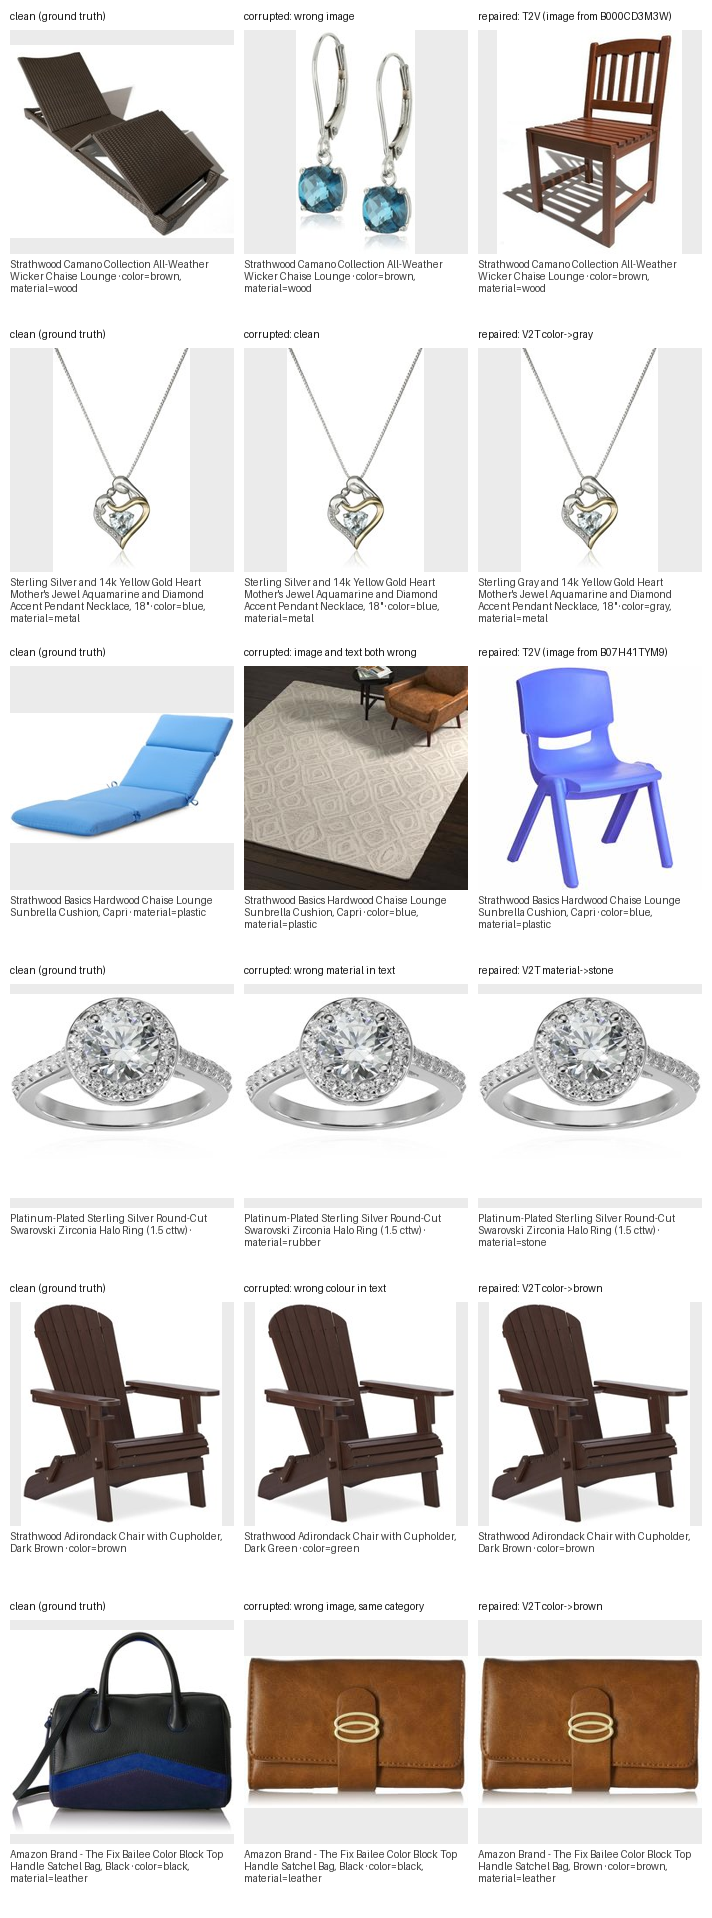

In [19]:
!python -m tiger.cli qualitative-grid --seed 7

from IPython.display import Image as _Image, display
from pathlib import Path as _Path
_g = _Path('paper_figures/qualitative_grid_final.png')
display(_Image(str(_g))) if _g.exists() else print('no grid: no repaired rows in this run')

### The generator, asked directly

The generative fallback is a **last resort**: it fires only when retrieval has no same-category candidate, which on a catalogue this size never happens — Full System and "No Generative Fallback" came back identical in every column on the previous run, which is what that means. So the grid above will not contain a synthesised image, and D10's question (does the model honour a pattern now that the prompt actually contains one?) has to be put to the generator directly.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|█████████████| 7/7 [00:01<00:00,  6.02it/s]
[solid] Professional studio product photo of a single brown wood chair, perfectly centered on a pure bright white background, studio lighting
[Generative Fallback] Synthesizing (SDXL-Turbo): 'brown wood chair'
[striped] Professional studio product photo of a single brown wood chair with a striped pattern, perfectly centered on a pure bright white background

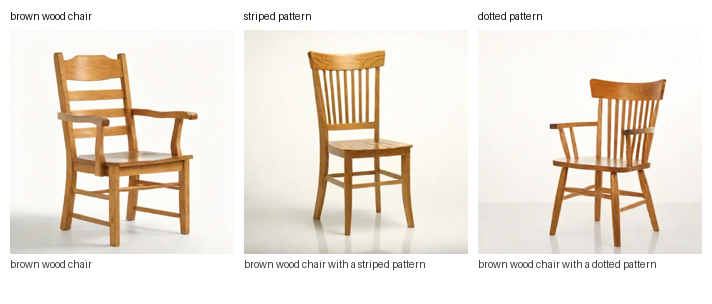

In [20]:
!python -m tiger.cli generate \
  --caption "a brown wooden dining chair" --category chair \
  --attrs '{"color":"brown","material":"wood"}' \
  --pattern-panel solid,striped,dotted \
  --output paper_figures/generation_pattern_panel.jpg

_p = _Path('paper_figures/generation_pattern_panel_panel.png')
display(_Image(str(_p))) if _p.exists() else print('no panel: generation did not run')

In [21]:
!cp -r data/outputs data/thresholds data/processed paper_figures /kaggle/working/ 2>/dev/null
# D10: the images the generative fallback just synthesised live under
# data/sample/ and used to be left behind on Kaggle, which is why the
# qualitative grid could never be rebuilt off-platform.
!mkdir -p /kaggle/working/generated && cp -r data/sample/images/generated/. /kaggle/working/generated/ 2>/dev/null
!cd /kaggle/working && zip -rq tiger_abo_corrected.zip outputs thresholds processed paper_figures generated
!ls -la /kaggle/working/tiger_abo_corrected.zip

# Free ~6GB: the raw ABO archives are no longer needed once the results zip above
# is built, and Kaggle bundles everything left in /kaggle/working/ into one
# output.zip when you download -- leaving this here means downloading the raw
# dataset a second time for no reason, on every future run.
!rm -rf /kaggle/working/abo
print("\n✅ Download tiger_abo_corrected.zip from the right sidebar.")

-rw-r--r-- 1 root root 258744776 Sep 14 12:06 /kaggle/working/tiger_abo_corrected.zip

✅ Download tiger_abo_corrected.zip from the right sidebar.


---
## After this run

1. **§7.5 of `paper_draft_materials.md` and H11 of `ROADMAP_PROGRESS.md` must be
   rewritten or withdrawn** (E3). They analyse an identity that A1 manufactured.
2. **§7.1's table is void** — those numbers came from a run with image repair
   disabled. Replace them with this run's.
3. **RQ3 can be answered properly for the first time.** Whatever the T2V column
   says here is the first real cross-domain image-repair evidence.
4. **H10's story survives but needs re-checking.** The `color` schema fix was a
   genuine finding; it just was not the only cause of the escalation rate.